# Bank-Distress Early-Warning — analysis notebook

This is the working notebook behind the FinLens AI surface. I build a discrete-time
hazard model on a per-bank-quarter FDIC Call Report panel, evaluate it strictly
out-of-time, and look at what drives it. Everything runs on the real DuckDB panel and
the real trained artifacts. I'm Surya Vaddhiparthy; this is how I actually built it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "pyproject.toml").exists():
    REPO = REPO.parent
for p in (REPO, REPO / "src", REPO / "ml"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.25})
from finlens_ml.config import get_ml_settings
from finlens_ml.features import FEATURE_COLUMNS, MONOTONE_CONSTRAINTS

## 1. The panel
One row per bank per quarter. The target is "does this bank fail within 4 quarters".

In [2]:
import duckdb

con = duckdb.connect(str(get_ml_settings().duckdb_path), read_only=True)
df = con.execute("select * from ml.training_dataset").df()
con.close()
df = df[df["label_4"].notna()].reset_index(drop=True)
df["label_4"] = df["label_4"].astype(int)
print(f"panel: {len(df):,} bank-quarters, {df['cert'].nunique():,} distinct banks")
print(f"positives (fail within 4q): {df['label_4'].sum():,} "
      f"({df['label_4'].mean():.3%} base rate)")
df[["cert", "quarter", "label_4"] + FEATURE_COLUMNS[:4]].head()

panel: 416,095 bank-quarters, 8,508 distinct banks
positives (fail within 4q): 2,138 (0.514% base rate)


,cert,quarter,label_4,log_assets,equity_to_assets,tier1_rwa_ratio,tier1_leverage
0,14,2008Q1,0,18.809149,7.724910,11.56,5.177675
1,14,2008Q2,0,18.748968,9.087560,13.43,6.416488
2,14,2008Q3,0,19.436964,4.171601,12.69,3.305137
3,14,2008Q4,0,18.958505,7.790149,19.76,7.838701
4,14,2009Q1,0,18.774557,9.945746,18.37,9.568757


A <1% base rate is the whole challenge: accuracy is useless here, so I lead with
precision-recall, recall@k, and calibration instead.

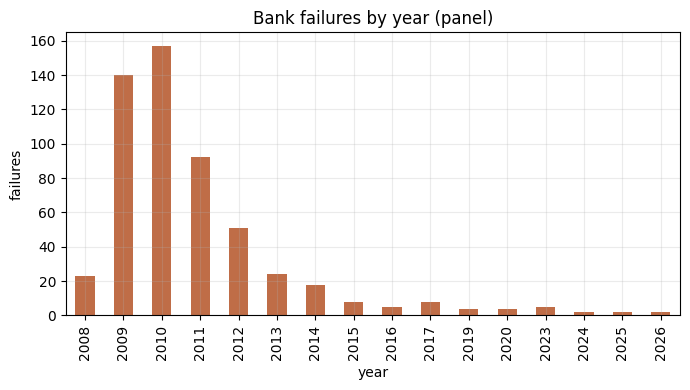

In [3]:
fails = df[df["fail_qord"].notna()].drop_duplicates("cert")
fails["fail_year"] = (fails["fail_qord"] // 4).astype(int)
by_year = fails.groupby("fail_year").size()
ax = by_year.plot(kind="bar", color="#bf6d47")
ax.set_title("Bank failures by year (panel)")
ax.set_xlabel("year")
ax.set_ylabel("failures")
plt.tight_layout()
plt.show()

## 2. Features and the monotone contract
34 CAMELS-aligned ratios, trends, and peer z-scores. Each feature carries an
economic monotone direction I enforce in the model so it can't learn a perverse
relationship (more capital must never raise predicted risk).

In [4]:
sign = {1: "raises risk", -1: "lowers risk", 0: "unconstrained"}
contract = pd.DataFrame(
    [{"feature": f, "monotone": sign[MONOTONE_CONSTRAINTS[f]]} for f in FEATURE_COLUMNS]
)
print(f"{len(FEATURE_COLUMNS)} features")
contract.head(12)

34 features


,feature,monotone
0,log_assets,unconstrained
1,equity_to_assets,lowers risk
2,tier1_rwa_ratio,lowers risk
3,tier1_leverage,lowers risk
4,noncurrent_to_loans,raises risk
5,nco_to_loans,raises risk
6,allowance_to_loans,unconstrained
7,roa,lowers risk
8,roe,lowers risk
9,nim,lowers risk


## 3. Out-of-time evaluation
I reuse the exact shipped protocol: train on the early panel, hold out the last 28
quarters (which contain real failures, including the 2023 cluster), with a reporting
lag embargo so nothing leaks. Then I calibrate the probabilities.

In [5]:
from finlens_ml.splits import final_holdout_split
from finlens_ml.train import EVAL_HOLDOUT_QUARTERS, _fit_calibrated, _fit_logit

X = df[FEATURE_COLUMNS].astype(float)
y = df["label_4"].to_numpy()
obs = df["obs_qord"]
tr_idx, te_idx = final_holdout_split(obs, horizon_q=4, holdout_quarters=EVAL_HOLDOUT_QUARTERS)
X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
X_te, y_te = X.iloc[te_idx], y[te_idx]
print(f"train: {len(tr_idx):,} rows | OOT test: {len(te_idx):,} rows, {y_te.sum()} failures")

eval_model, eval_cal, method, spw, best_it = _fit_calibrated(X_tr, y_tr, 42)
logit = _fit_logit(X_tr, y_tr)
p_cal = eval_cal.predict_proba(X_te)[:, 1]
p_logit = logit.predict_proba(X_te)[:, 1]

train: 275,822 rows | OOT test: 118,943 rows, 66 failures


Calibrated LGBM  PR-AUC=0.1563  ROC-AUC=0.8293
Logit benchmark  PR-AUC=0.1093  ROC-AUC=0.9192


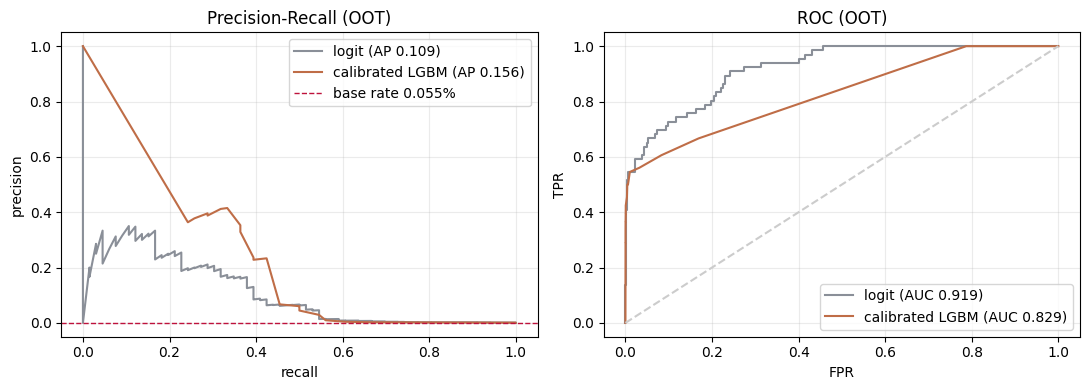

In [6]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

print(f"Calibrated LGBM  PR-AUC={average_precision_score(y_te, p_cal):.4f}  "
      f"ROC-AUC={roc_auc_score(y_te, p_cal):.4f}")
print(f"Logit benchmark  PR-AUC={average_precision_score(y_te, p_logit):.4f}  "
      f"ROC-AUC={roc_auc_score(y_te, p_logit):.4f}")

fig, (axp, axr) = plt.subplots(1, 2, figsize=(11, 4))
for p, name, c in [(p_logit, "logit", "#8a8f98"), (p_cal, "calibrated LGBM", "#bf6d47")]:
    prec, rec, _ = precision_recall_curve(y_te, p)
    axp.plot(rec, prec, label=f"{name} (AP {average_precision_score(y_te, p):.3f})", color=c)
    fpr, tpr, _ = roc_curve(y_te, p)
    axr.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, p):.3f})", color=c)
axp.axhline(y_te.mean(), ls="--", c="#be123c", lw=1, label=f"base rate {y_te.mean():.3%}")
axp.set(title="Precision-Recall (OOT)", xlabel="recall", ylabel="precision")
axr.plot([0, 1], [0, 1], ls="--", c="#ccc")
axr.set(title="ROC (OOT)", xlabel="FPR", ylabel="TPR")
axp.legend(); axr.legend(); plt.tight_layout(); plt.show()

The LGBM beats the regulatory-style penalized logit on PR-AUC, which is the metric
that matters at this base rate. ROC looks strong for both, which is exactly why I
don't lead with it.

## 4. Calibration
A served probability should mean what it says. I bin the OOT predictions and compare
predicted vs observed failure rate.

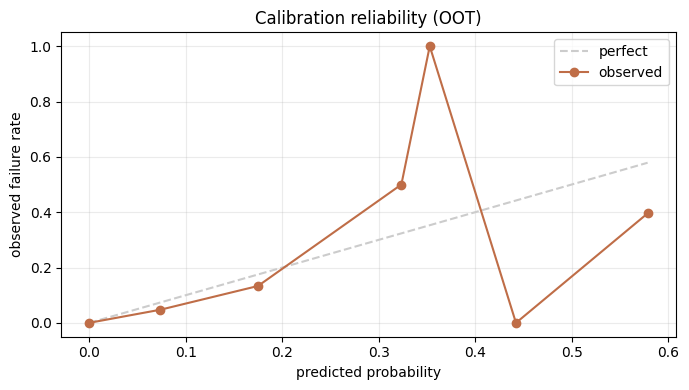

In [7]:
bins = np.linspace(0, p_cal.max(), 11)
idx = np.clip(np.digitize(p_cal, bins) - 1, 0, 9)
pred = [p_cal[idx == b].mean() for b in range(10) if (idx == b).sum()]
obsr = [y_te[idx == b].mean() for b in range(10) if (idx == b).sum()]
plt.plot([0, max(pred)], [0, max(pred)], ls="--", c="#ccc", label="perfect")
plt.plot(pred, obsr, "o-", c="#bf6d47", label="observed")
plt.title("Calibration reliability (OOT)")
plt.xlabel("predicted probability"); plt.ylabel("observed failure rate")
plt.legend(); plt.tight_layout(); plt.show()

## 5. What drives it — SHAP
Global attribution over a sample of the panel, using the served booster.

C:\Creations\Legacy\FinLens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Creations\Legacy\FinLens\.venv\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


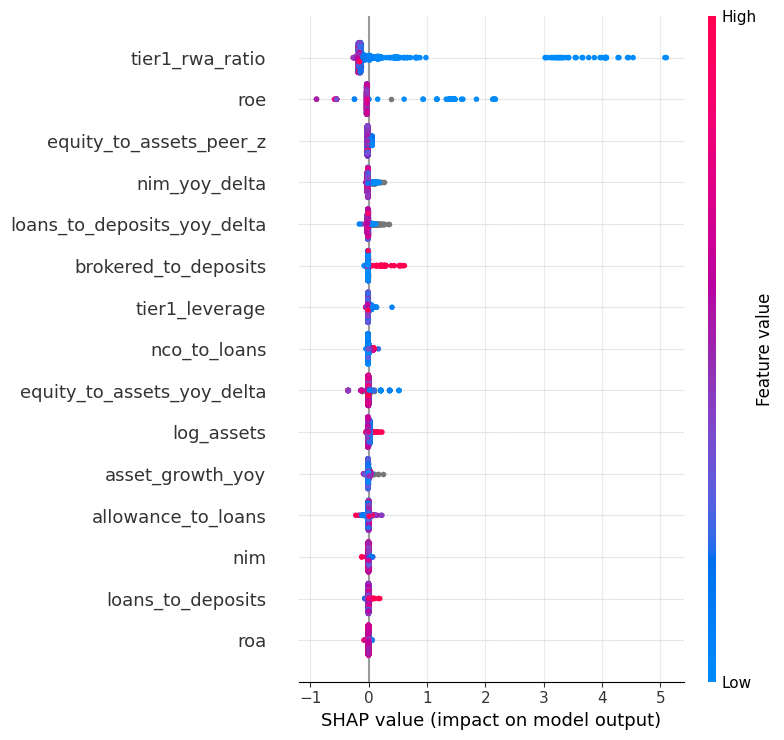

In [8]:
import shap
import lightgbm as lgb

booster = lgb.Booster(model_file=str(REPO / "ml" / "artifacts" / "booster_h4.txt"))
sample = df.sample(n=min(2000, len(df)), random_state=42)[FEATURE_COLUMNS].astype(float)
expl = shap.TreeExplainer(booster, feature_perturbation="tree_path_dependent")
sv = expl.shap_values(sample)
if isinstance(sv, list):
    sv = sv[1] if len(sv) > 1 else sv[0]
shap.summary_plot(sv, sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

Capital adequacy (Tier 1 / RWA), profitability (ROE), and the rate-risk / funding
features dominate, in the directions the monotone contract enforces.

## 6. Takeaways
- Discrete-time hazard on a bank-quarter panel, evaluated strictly out-of-time.
- Calibrated probabilities, monotone-constrained, benchmarked against a penalized logit.
- Honest about the rate-risk blind spot: a purely credit-driven model under-weights a
  2023-style liquidity run, which is why HTM/uninsured-deposit features are in the set.
- Everything here is reproducible from the public FDIC panel at $0.